In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("infection_lookup.csv")

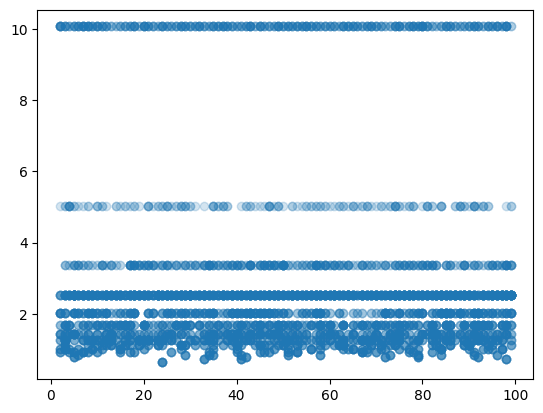

In [3]:
plt.scatter(df["infection_age"], df["gametocyte_density"], alpha=0.1)

In [4]:
np.mean(df["gametocyte_density"])

2.632116366829151

In [5]:
df.columns

Index(['infection_id', 'human_id', 'duration', 'aggregate_gametocyte_density',
       'infection_age', 'gametocyte_density'],
      dtype='object')

11.82528714965453

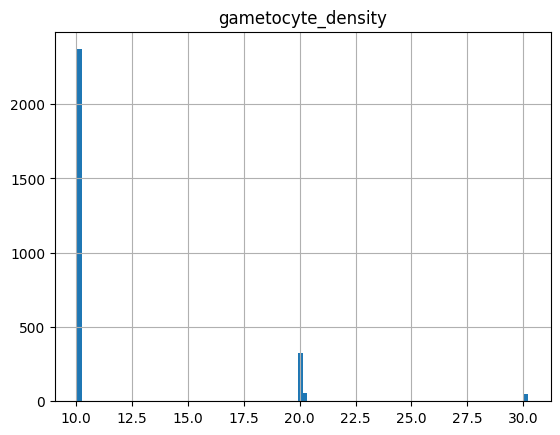

In [8]:
foo = df.groupby("human_id").agg({"gametocyte_density": "sum"})

foo.hist(bins=100)

np.mean(foo["gametocyte_density"])

In [9]:
def infectiousness_from_gametocyte_density(gametocyte_density):
    # EMOD function which relates gametocyte density to infectiousness
    base_gametocyte_mosquito_survival = 0.002011099
    return 1 - np.exp(-base_gametocyte_mosquito_survival * gametocyte_density)

In [10]:
df["infectiousness"] = df["gametocyte_density"].apply(infectiousness_from_gametocyte_density)

In [11]:
np.mean(df["infectiousness"])

0.005268999061413469

0.023671987940082895

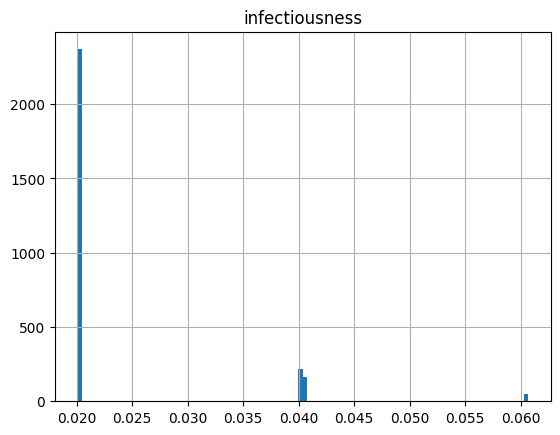

In [12]:
foo = df.groupby("human_id").agg({"infectiousness": "sum"})

foo.hist(bins=100)

np.mean(foo["infectiousness"])

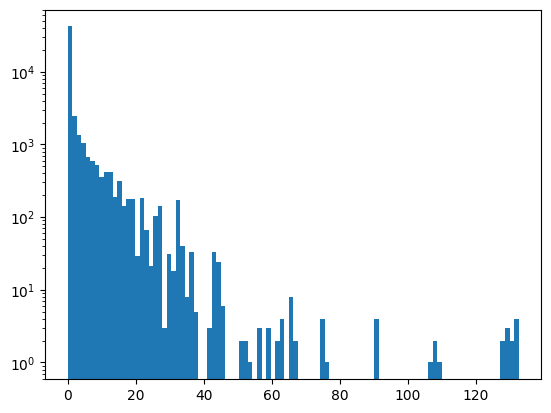

In [12]:
plt.hist(df["gametocyte_density"], bins=100)
plt.yscale("log")

(array([4.952e+04, 1.737e+03, 5.540e+02, 8.800e+01, 1.100e+01, 1.900e+01,
        2.000e+00, 4.000e+00, 4.000e+00, 1.100e+01]),
 array([0.        , 0.02338854, 0.04677707, 0.07016561, 0.09355415,
        0.11694269, 0.14033122, 0.16371976, 0.1871083 , 0.21049684,
        0.23388537]),
 <BarContainer object of 10 artists>)

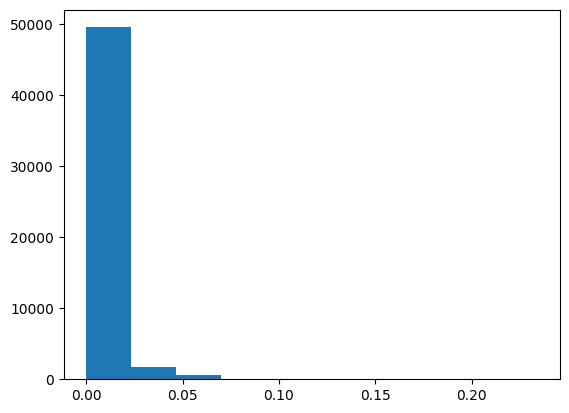

In [8]:
plt.hist(df["infectiousness"])